### 第1章 Matplotlib 基础
#### 1.1 常用图表设置

- `matplotlib.pyplot.plot(x, y, *args, **kwargs)` 主要用于绘制线型图和坐标轴的标记
- `matplotlib.pyplot.figure(num=None, figsize=None, dpi=None, facecolor=None, edgecolor=None, frameon=True)` 用来设置画布
    - `num` 图像的编号和名称，数字为编号，字符串为名称，可以通过该参数激活不同的画布
    - `figsize` 图像的尺寸，以英寸为单位
    - `dpi` 图像的分辨率，即每英寸多少个像素，默认值为80
    - `facecolor` 图像的背景颜色
    - `edgecolor` 图像边框的颜色
    - `frameon` 是否显示边框，默认值为True，绘制边框；如果为False，则不绘制边框
- `matplotlib.pyplot.title(label, fontict=None, loc='center', pad=None, **kwargs)` 用来设置图表标题
    - `label` 图表标题文本字符串
    - `fontict` 字体属性样式字典，例如{'fontsize': 12, 'fontweight':20, 'va':'bottom', 'ha':'center'}
    - `loc` 标题的位置，可以是'left', 'center', 'right'
    - `pad` 浮点数，表示标题与图表边缘的距离，默认值为None

- 线条颜色
    - `b` 蓝色；`r` 红色；`g` 绿色；`c` 青色；`m` 品红；`y` 黄色；`k` 黑色；`w` 白色
- 线条样式
    - `-` 实线，默认值；`--` 破折线；`-.` 点划线；`:` 虚线
- 标记样式
    - `.` 点；`,` 像素；`o` 实心圆；`s` 实心正方形；`p` 实心五角星；`*` 星形线
    - `h` 竖六边形；`H` 横六边形；`+` 加号；`x` x号；`D` 实心菱形；`d` 菱形
    - `^` 上三角；`v` 下三角；`>` 右三角；`<` 左三角
    - `1` 三角向下（实心）；`2` 三角向上（实心）；`3` 三角向左（实心）； `4` 三角向右（实心）

In [ ]:
# 全局设置 Matplotlib 自动循环使用这组颜色
from cycler import cycler
import matplotlib.pyplot as plt

# 10种颜色，分别是蓝色、橙色、绿色、红色、紫色、棕色、粉色、灰色、黄绿色和青色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] 
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

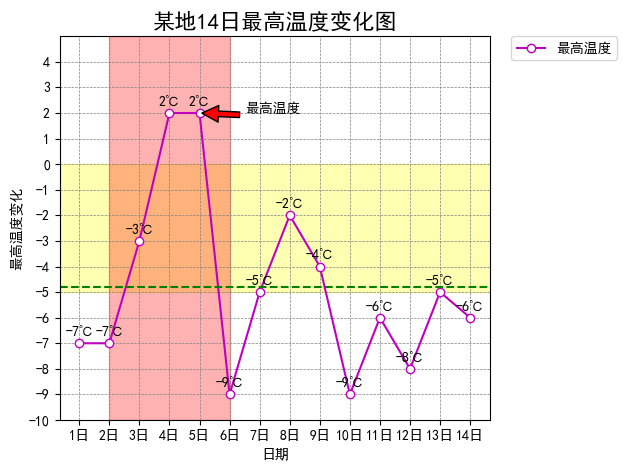

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码
plt.rcParams["axes.unicode_minus"] = False      # 解决负号不显示

df = pd.read_excel("../datas/天气.xlsx")  # 读取Excel文件 
x = df["日期"]  # x轴数据
y = df["最高温度"]  # y轴数据
plt.plot(x, y, color='m', linestyle='-', marker='o', mfc='w')

plt.xlabel("日期")  # 设置x轴标签
plt.ylabel("最高温度变化")

# 设置坐标轴和坐标刻度
plt.ylim(-10, 5)  # 设置y轴的范围
plt.yticks(range(-10, 5, 1))  # 设置y轴显示的刻度，本程序中默认显示间隔为2

# 添加文本标签
for a, b in zip(x, y):
    plt.text(a, b+0.2, '%.0f'%b+'℃', ha='center', va='bottom', fontsize=10)  # 在数据点上显示数值

# 设置标题和图例
plt.title("某地14日最高温度变化图", fontsize=16)  # 设置图表标题

# plt.legend(["最高温度"], loc='upper right', fontsize=10)        # 显示图例，图例右上角对齐（放在图的右上角）
plt.legend(["最高温度"], bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)  # 将图例左上角放在指定点

# 添加注释
plt.annotate("最高温度", 
             xy=(4, 2),         # 注释箭头指向的位置
             xytext=(5.5, 2),   # 注释文本的位置
             xycoords='data',   # 注释箭头指向的位置的坐标系
             arrowprops=dict(facecolor='r', shrink=0.05)    # 注释箭头样式
             )  # 添加注释

# 设置网格线
plt.grid(color='gray', linestyle='--', linewidth=0.5)  # 添加网格线，设置颜色、线型和线宽

# 绘制参考线
mean_temp = y.mean()  # 计算平均温度
plt.axhline(mean_temp, color='g', linestyle='--')  # 添加水平线，表示平均温度

# 选取范围
plt.axhspan(ymin=-5, ymax=0, color='yellow', alpha=0.3)  # 添加水平区域，表示温度在-5到0之间的范围
plt.axvspan(xmin=1, xmax=5, color='red', alpha=0.3)  # 添加垂直区域，表示特定日期范围

plt.tight_layout()  # 调整布局，避免标签重叠
plt.savefig("天气变化图.png", dpi=300)  # 保存图表为PNG文件，设置分辨率为300dpi

plt.show()  # 显示图表

#### 1.2 常用图表的绘制
##### 1. 折线图
- 折线图可以显示随时间变化的连续数据，非常适合展示在相同时间间隔下数据的趋势
- 在折线图中，类别数据沿X轴均匀分布，数值数据沿Y轴均匀分布

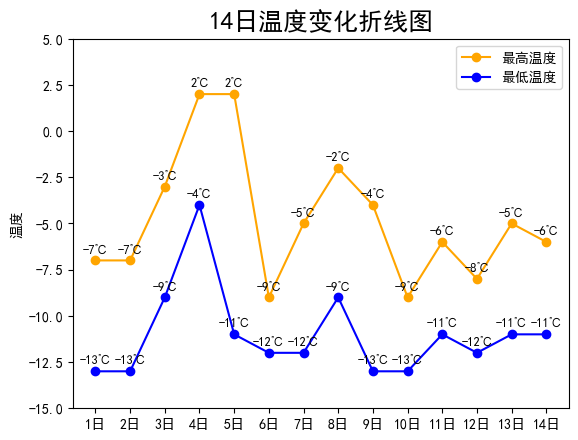

In [7]:
# 导入相关模块
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码
plt.rcParams["axes.unicode_minus"] = False  # 解决负号不显示

df = pd.read_excel("../datas/天气.xlsx")  # 读取Excel文件
x = df["日期"]      # x轴数据
y1 = df["最高温度"]  # y轴数据
y2 = df["最低温度"]

# 绘制折线图
plt.plot(x, y1, label="最高气温", color="orange", marker="o")
plt.plot(x, y2, label="最低气温", color="blue", marker="o")
plt.ylabel("温度")  # y轴标题
plt.title(label="14日温度变化折线图", fontsize="18")  # 图表标题
plt.ylim(-15, 5)    # y轴范围
# 添加文本标签
for a, b in zip(x, y1):
    plt.text(a, b + 0.3, "%.0f" % b + "℃", ha="center", va="bottom", fontsize=9)
for a, b in zip(x, y2):
    plt.text(a, b + 0.3, "%.0f" % b + "℃", ha="center", va="bottom", fontsize=9)
plt.legend(["最高温度", "最低温度"])  # 图例
plt.show()  # 显示图表

##### 2. 柱形图
- 柱形图，又称长条图、柱状图，是一种以长方形的长度为变量的统计图表
- `matplotlib.pyplot.bar(x, height, width, bottom=None, *, align='center', data=None, **kwargs)` 用来绘制柱形图，其中
    - `x` 是x轴的标签列表
    - `height` 是柱形的高度，也就是y轴数据
    - `width` 是柱形的宽度，浮点数，默认值是0.8
    - `bottom` 是柱形底部y轴的位置，标量或数组，默认是0
    - `align` 是柱形的对齐方式，可以是'center', 'edge'，默认是'center'
    - `data` 是传递给绘图函数的NumPy数组或类似数组对象，默认为None
    - `**kwargs` 是其他关键字参数

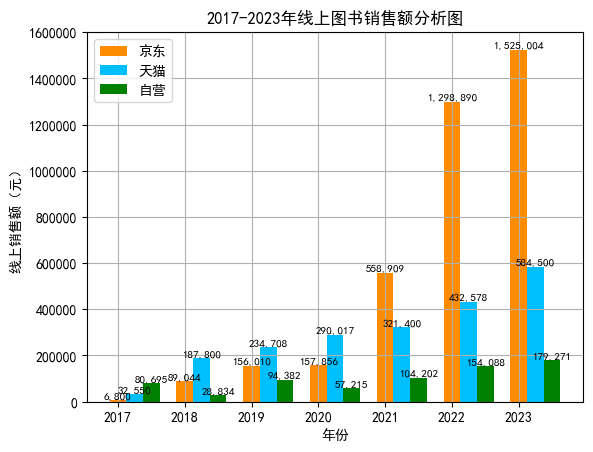

In [ ]:
# 导入相关模块
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif']=['SimHei'] # 解决中文乱码

df = pd.read_excel(io="../datas/books.xlsx", sheet_name="Sheet2")   # 读取Excel文件
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)   # 取消y轴数据采用科学记数法
x = df['年份']
y1 = df['京东']
y2 = df['天猫']
y3 = df['自营']
width = 0.25    # 柱子宽度，若显示n个柱子，则width值需小于1/n ，否则柱子会出现重叠
# xy轴标签
plt.xlabel('年份')
plt.ylabel('线上销售额（元）')
# 图表标题
plt.title('2017-2023年线上图书销售额分析图')
# 绘制柱形图
plt.bar(x, y1, width=width, color='darkorange')
plt.bar(x+width, y2, width=width, color='deepskyblue')
plt.bar(x+2*width, y3, width=width, color='g')
# 设置每个柱子的文本标签,format(b,',')格式化销售额为千位分隔符格式
for a,b in zip(x,y1):
    plt.text(a, b,format(b,','), ha='center', va= 'bottom',fontsize=8)
for a,b in zip(x,y2):
    plt.text(a+width, b,format(b,','), ha='center', va= 'bottom',fontsize=8)
for a, b in zip(x, y3):
    plt.text(a + 2*width, b, format(b, ','), ha='center', va='bottom', fontsize=8)
plt.legend(['京东','天猫','自营'])# 图例
plt.grid()                        # 网格
plt.show()                        # 显示图表

##### 3. 直方图
- 直方图，又称质量分布图，以一系列高度不等的条形图来表示数据分布情况。一般用横轴表示数据类别，纵轴表示频数。
- `matplotlib.pyplot.hist(x, bins=None, range=None, density=False, hsttype='bar', align='mid', log=False, color=None, label=None, stacked=False)` 用来绘制直方图，其中
    - `x` 是数据集
    - `bins` 是统计数据的区间分布
    - `range` 是元组，指定显示的区间
    - `density` 默认值为False，显示频数统计结果；若为True，则显示概率统计结果，`频率统计结果 = 区间数目 / (总数\times区间宽度)` （单位宽度的数据密度）
    - `histtype` 直方图的类型，默认为'bar'，即条形图；可选的还有['barstacked', 'step'(梯状), 'stepfilled'(填充后的梯状)]
    - `align` 控制柱形图的水平分布，默认为'mid'，即中间对齐；可选的还有['left', 'right']
    - `log` 控制是否显示对数坐标，默认为False
    - `stacked` 控制是否堆叠直方图，默认为False

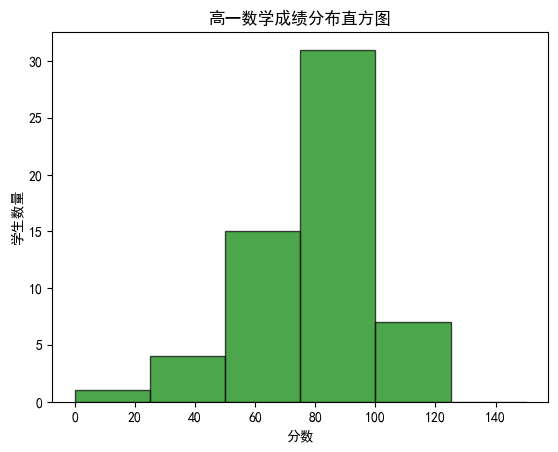

In [18]:
# 导入相关模块
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码
df = pd.read_excel(io="../datas/grade.xlsx", sheet_name="数学") # 读取Excel文件

x = df["得分"]  # x轴数据
plt.xlabel("分数")  # x轴标题
plt.ylabel("学生数量")  # y轴标题
plt.title("高一数学成绩分布直方图")  # 图表标题
# 绘制直方图
plt.hist(
    x,
    bins=[0, 25, 50, 75, 100, 125, 150],
    facecolor="green",
    edgecolor="black",
    alpha=0.7,
)
plt.show()  # 显示图表

##### 4. 饼图
- 饼图常用来显示各组成部分占整体的比例
- `matplotlib.pyplot.pie(x, explode=None, labels=None, colors=None, autopct=None, pctdistance=0.6, shadow=False, labeldistance=1.1, startangle=None, radius=None, counterclock=True, wedgeprops=None, textprops=None, center=(0,0), frame=False, rotatelabels=False, hold=None, data=None)` 
    - `x` 是数据数组，表示每个扇形的大小，会被自动归一化
    - `explode` 与 x 长度相同的数组，指定每个扇区偏离中心的距离，默认表示不偏离中心
    - `labels` 字符串列表，表示每个扇区外侧显示的标签，默认不显示
    - `autopct` 格式字符串，用于显示扇形百分比
    - `pctdistance` 百分比标签与饼图中心的距离
    - `shadow` 是否显示阴影，默认不绘制阴影
    - `labeldistance` 标签与饼图中心的距离，如果值小于1，则绘制在扇形内侧
    - `startangle` 起始角度，默认从x轴正方向逆时针开始；如果设置为90，则从y轴正方向开始
    - `radius` 饼图的半径，默认为1
    - `counterclock` 布尔值，是否逆时针绘制，默认逆时针
    - `wedgeprops` 字典，用于设置扇形边框的属性
    - `textprops` 字典，用于设置文本标签的属性
    - `center` 饼图的中心点，默认为(0,0)
    - `frame` 是否绘制饼图网格，默认不显示。如果设置为True，需要与`grid()`一起使用，建议为False
    - `rotatelabels` 布尔值，是否自动旋转文本标签，默认为False

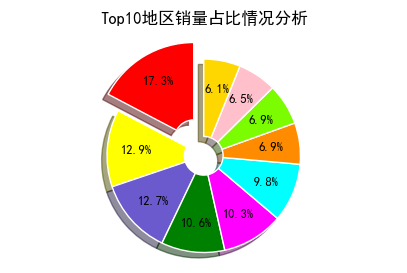

In [34]:
# 导入相关模块
import pandas as pd
from matplotlib import pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码
df1 = pd.read_excel(io="../datas/address.xlsx", sheet_name="Sheet2")  # 读取Excel文件
plt.figure(figsize=(5, 3))  # 设置画布大小
labels = df1["地区"]
sizes = df1["销量"]
# 设置饼形图每块的颜色
colors = [
    "red",
    "yellow",
    "slateblue",
    "green",
    "magenta",
    "cyan",
    "darkorange",
    "lawngreen",
    "pink",
    "gold",
]
plt.pie(
    sizes,  # 绘图数据
    explode=(0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0,),  # 设置突出显示的扇区，这里只对第一个扇区进行突出显示    labels=labels,  # 添加地区标签
    colors=colors,  # 设置每个扇区的自定义填充色
    labeldistance=1.02,  # 设置每个扇区标签（图例）与中心的距离
    autopct="%.1f%%",  # 设置百分比的格式，这里保留一位小数
    startangle=90,  # 设置饼形图的初始角度
    radius=0.5,  # 设置饼形图的半径
    center=(0.2, 0.2),  # 设置饼形图中心的位置
    wedgeprops = {'width': 0.4, 'edgecolor': 'w'},  # 设置扇形的宽度和边缘颜色
    textprops={"fontsize": 9, "color": "k"},  # 设置文本标签的属性值
    pctdistance=0.7,    # 设置百分比标签与中心的距离
    shadow=True,  # 设置饼形图是否有阴影效果
)  # 设置百分比标签与中心的距离
# 设置XY轴刻度一致，保证饼图为圆形
plt.axis("equal")
plt.title("Top10地区销量占比情况分析")  # 图表标题
plt.show()  # 显示图表

- 环形图是由两个或两个以上的扇形连在一起，挖去中间部分所构成的图形
- 内嵌环形图实际是双环形图：
    - 连续使用两次`pie()`函数
    - 通过`wedgeprops`参数设置内外环形的样式
    - 通过`radius`设置不同的半径

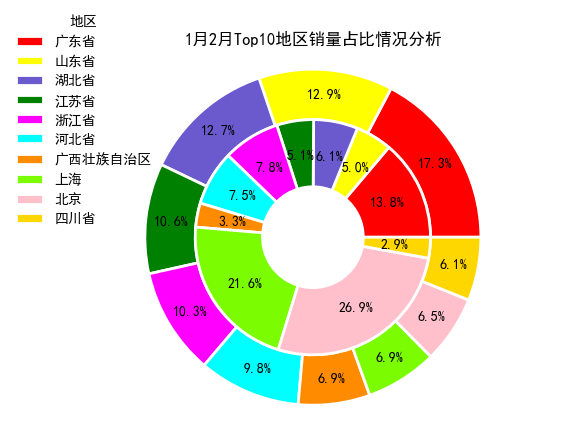

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
df1 = pd.read_excel(io="../datas/address.xlsx", sheet_name="Sheet2")
df2 = pd.read_excel(io="../datas/address.xlsx", sheet_name="1月")
# 数据集，x1,x2分别对应外环、内环百分比例
x1 = df1["销量"]
x2 = df2["销量"]
# 设置饼状图各个区块的颜色
colors = [
    "red",
    "yellow",
    "slateblue",
    "green",
    "magenta",
    "cyan",
    "darkorange",
    "lawngreen",
    "pink",
    "gold",
]
# 外环
plt.pie(
    x1,
    autopct="%.1f%%",
    radius=1,
    pctdistance=0.85,
    colors=colors,
    wedgeprops=dict(linewidth=2, width=0.3, edgecolor="w"),
)
# 内环
plt.pie(
    x2,
    autopct="%.1f%%",
    radius=0.7,
    pctdistance=0.7,
    colors=colors,
    wedgeprops=dict(linewidth=2, width=0.4, edgecolor="w"),
)
# 图例
legend_text = df1["地区"]
plt.legend(
    legend_text, title="地区", frameon=False, bbox_to_anchor=(0.2, 0.5)
)  # 设置图例标题、位置、去掉图例边框
plt.axis("equal")  # 设置坐标轴比例以显示为圆形
plt.title("1月2月Top10地区销量占比情况分析")
plt.show()

##### 5. 散点图
- 散点图主要用来查看数据的分布情况或相关性，一般用在线性回归中，查看数据点在坐标平面上的分布情况
- `matplotlib.pyplot.scatter(x, y, s=None, c=None, marker=None, cmap=None, norm=None, vmin=None, vmax=None, alpha=None, linewidths=None, verts=None, edgecolors=None, data=None, **kwargs)`
    - x, y：数据数组，表示散点图中的横坐标和纵坐标
    - s：指定每个点的大小。如果是标量，则所有点大小相同；如果是数组，则可以指定每个点的不同大小，默认值为20
    - c：点的颜色，默认值是b（蓝色）
    - marker：点的形状，默认值是o（圆形）
    - cmap：指定colormap，用于映射颜色，默认值是None
    - norm：指定colormap的归一化方法，默认值是None
    - vmin, vmax：浮点数，表示色彩映射的下限和上限
    - alpha：浮点数，指定点的透明度，其中0代表完全透明，1代表不透明
    - linewidths：浮点数或数组，指定点的边缘宽度
    - edgecolors：点的边缘颜色，可选值有'face'（与点的颜色相同）, 'none'（无边缘）或其他颜色规范

ValueError: could not convert string to float: '支出'

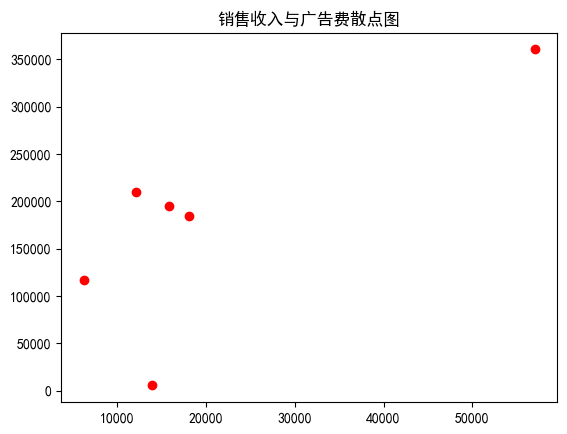

In [7]:
# 导入相关模块
import pandas as pd
import matplotlib.pyplot as plt

# 读取Excel文件
dfaa = pd.DataFrame(pd.read_excel("../datas/JDdata.xlsx"))
dfbb = pd.DataFrame(pd.read_excel("../datas/JDcar.xlsx"))
# 抽取数据
df1 = dfaa[["业务日期", "金额"]]
df2 = dfbb[["投放日期", "支出"]]
# 去除空日期和金额为0的记录
df1 = df1[df1["业务日期"].notnull() & df1["金额"] != 0]
df2 = df2[df2["投放日期"].notnull() & df2["支出"] != 0]
# 转换为日期格式并设置索引
df1["业务日期"] = pd.to_datetime(df1["业务日期"])   # df1.shape = (24541, 2)
df2["投放日期"] = pd.to_datetime(df2["投放日期"])   # df2.shape = (181, 2)

dfData = df1.set_index("业务日期", drop=True)
dfCar = df2.set_index("投放日期", drop=True)
# 按月度统计并显示销售金额
dfData_month = dfData.resample("ME").sum().to_period("M")
# 按月度统计并显示广告费支出金额
dfCar_month = dfCar.resample("ME").sum().to_period("M")

# x为广告费用，y为销售收入
x = pd.DataFrame(dfCar_month["支出"])
y = pd.DataFrame(dfData_month["金额"])
plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码
plt.title("销售收入与广告费散点图")               # 图表标题
plt.scatter(x, y, color="red")                  # 真实值散点图

for a, b in zip(x, y):
    plt.text(float(a), float(b) + 0.3, "%s" % b, ha="center", va="bottom", fontsize=9)

plt.show()  # 显示图表


##### 6. 面积图
- 面积图用于体现数量随时间变化的程度，也可用于引起对总值趋势的注意

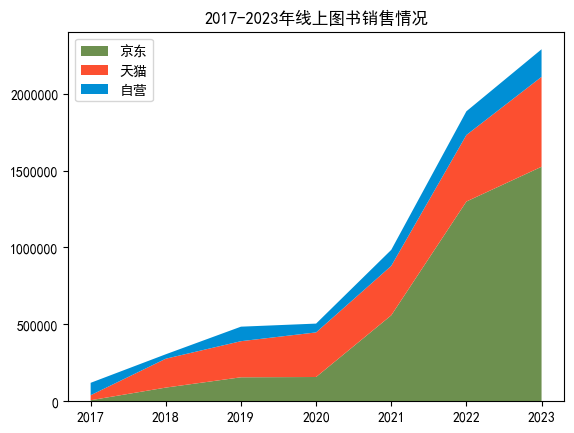

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(io="../datas/books.xlsx", sheet_name="Sheet2")
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码
# 取消科学记数法
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
# x、y轴数据
x = df["年份"]
y1 = df["京东"]
y2 = df["天猫"]
y3 = df["自营"]
plt.title("2017-2023年线上图书销售情况")  # 图表标题
# 堆叠面积图
plt.stackplot(x, y1, y2, y3, colors=["#6d904f", "#fc4f30", "#008fd5"])
plt.legend(["京东", "天猫", "自营"], loc="upper left")  # 图例
plt.show()  # 显示图表

##### 7. 箱线图
- 箱线图又称盒须图或盒式图，是一种用于显示一组数据分布情况资料的统计图。箱线图能够显示出一组数据的最大值、最小值、中位数和四分位数的信息，并能直观地看出数据是否具有对称性，分布的分散程度等情况
- `matplotlib.pyplot.boxplot(x, notch=None, sym=None, vert=None, whis=None, positions=None, widths=None, patch_artist=None, meanline=None, showmeans=None, showcaps=None, showbox=None, showfliers=None, boxprops=None, tick_labels=None, flierprops=None, meanprops=None, medianprops=None, whiskerprops=None, capprops=None)`
    - `x`：绘制箱线图的数据，可以是向量或者列表
    - `notch`：是否以凹口形式展现箱线图，默认为 False
    - `sym`：绘制箱线图时，指定异常点的标记符号，默认为‘+’
    - `vert`：是否垂直绘制箱线图，默认为 True
    - `whis`：指定箱线图的上、下限与上下四分位的距离，默认为 1.5 倍的四分位距
    - `positions`：指定箱线图的位置，默认为 1 到 n 的序列
    - `widths`：指定箱线图的宽度，默认为 0.5
    - `patch_artist`：是否使用填充颜色绘制箱线图，默认为 False
    - `meanline`：是否绘制均值线，默认为 False，即用点来表示
    - `showmeans`：是否显示均值，默认为 False
    - `showcaps`：是否显示箱线图的上下限，默认为 True
    - `showbox`：是否显示箱体，默认为 True
    - `showfliers`：是否显示异常点，默认为 True
    - `boxprops`：设置箱体属性，默认为 None
    - `tick_labels`：设置箱线图的标签，默认为 None
    - `flierprops`：设置异常点属性，默认为 None
    - `meanprops`：设置均值线属性，默认为 None
    - `medianprops`：设置中位数属性，默认为 None
    - `whiskerprops`：设置箱线图的上、下限属性，默认为 None
    - `capprops`：设置箱线图的上、下限末端属性，默认为 None

- 下四分位（Q1）：将所有数值由小到大排列后，处于数据 25% 分位点所对应的值
- 中位数（Q2）：将所有数值由小到大排列后，处于数据 50% 分位点所对应的值
- 上四分位（Q3）：将所有数值由小到大排列后，处于数据 75% 分位点所对应的值
- 上限：$Q3 + 1.5 \times (Q3 - Q1)$
- 下限：$Q1 - 1.5 \times (Q3 - Q1)$
- 若变量的数据值大于箱线图的上限，或者小于箱线图的下限，则认为该数据值是异常值

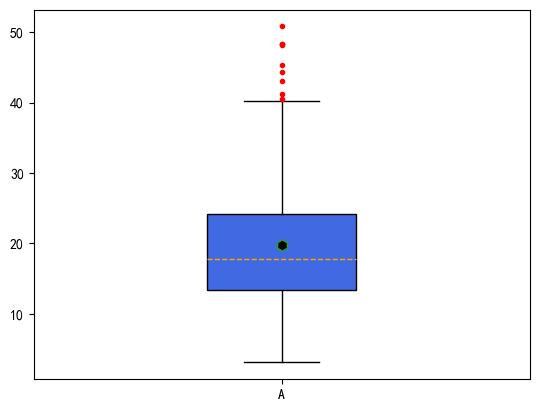

异常值如下：
26     44.30
77     43.11
131    48.27
163    48.17
171    50.81
182    45.35
184    40.55
194    48.33
230    41.19
Name: 总消费, dtype: float64


In [9]:
import matplotlib.pyplot as plt  
import pandas as pd  

df = pd.read_excel("../datas/tips.xlsx")  # 读取Excel文件
plt.boxplot(
    x=df["总消费"],  # 指定绘制箱线图的数据
    whis=1.5,       # 指定1.5倍的四分位差
    widths=0.3,     # 指定箱线图中箱子的宽度为0.3
    patch_artist=True,  # 填充箱子颜色
    showmeans=True,  # 显示均值
    boxprops={"facecolor": "RoyalBlue"},  # 指定箱子的填充色为宝蓝色
    # 指定异常值的填充色、边框色和大小
    flierprops={"markerfacecolor": "red", "markeredgecolor": "red", "markersize": 3},
    # 指定中位数的标记符号（六边形）、填充色和大小
    meanprops={"marker": "h", "markerfacecolor": "black", "markersize": 8},
    # 指定均值点的标记符号（虚线）、颜色
    medianprops={"linestyle": "--", "color": "orange"},
    tick_labels=["A"],  # 指定x轴刻度标签 'labels'被替换为'tick_labels'
)
plt.show()  # 显示图表
# 计算下四分位数和上四分位
Q1 = df["总消费"].quantile(q=0.25)
Q3 = df["总消费"].quantile(q=0.75)
# 基于1.5倍的四分位差计算上下限对应的值
low_limit = Q1 - 1.5 * (Q3 - Q1)
up_limit = Q3 + 1.5 * (Q3 - Q1)
# 查找异常值
val = df["总消费"][(df["总消费"] > up_limit) | (df["总消费"] < low_limit)]
print("异常值如下：")
print(val)

##### 8. 热力图
- 热力图通过颜色的变化来表示数据的密度、频率、强度或其他类别的数值信息，通常用于展示二维数据集中的数值分布情况

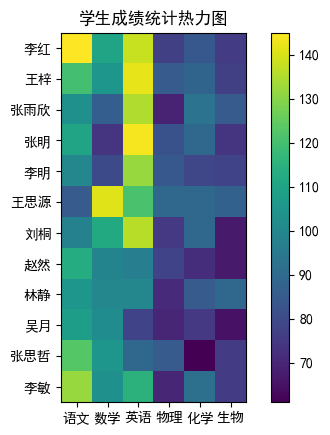

In [10]:
import pandas as pd  # 导入pandas模块
import matplotlib.pyplot as plt  # 导入matplotlib模块

# 读取Excel文件名为“高二一班”的Sheet页中的数据
df = pd.read_excel("../datas/data1.xlsx", sheet_name="高二一班")
plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码
X = df.loc[:, "语文":"生物"].values             # 抽取“语文”至“生物”的成绩
name = df["姓名"]   # 抽取“姓名”
plt.imshow(X)       # 绘制热力图
plt.xticks(
    range(0, 6, 1), ["语文", "数学", "英语", "物理", "化学", "生物"]
)  # 设置x轴刻度标签
plt.yticks(range(0, 12, 1), name)  # 设置y轴刻度标签
plt.colorbar()  # 显示颜色条
plt.title("学生成绩统计热力图")  # 设置图表标题
plt.show()      # 显示图表

##### 9. 雷达图
- 雷达图可以把多个维度的数据在同一个图表上展示出来，适合表现整体水平，反映各部分之间的关系
- `plt.polar(theta, r, **kwargs)` 用于在极坐标系上绘制折线图
    - `theta` 标量或标量序列，设置数据点的极径
    - `r` 标量或标量序列，设置数据点的极角
    - `**kwargs` 指定线的其他特性

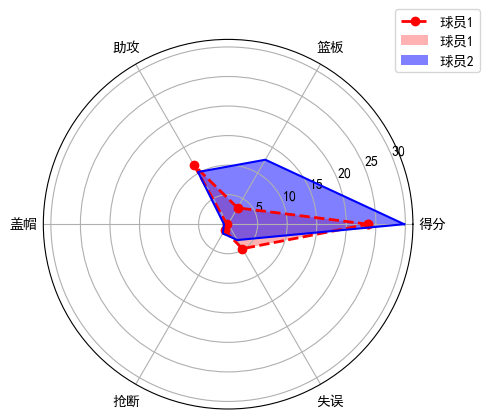

In [28]:
import pandas as pd							# 导入pandas模块
import matplotlib.pyplot as plt					# 导入matplotlib模块
import numpy as np								# 导入numpy模块
# 读取Excel文件，设置“球员”为索引
df = pd.read_excel('../datas/成绩表.xlsx',sheet_name='Sheet2',index_col='球员')
# 解决中文乱码
plt.rcParams['font.sans-serif']=['SimHei']
# 类别标签
labels = np.array(['得分','篮板', '助攻','盖帽', '抢断','失误'])
# 获取列数
dataLenth = df.shape[1]         # df.shape = (3, 6)
# 抽取球员成绩
y1 = df.iloc[0,:]
y2 = df.iloc[1,:]
# 生成与列数一样的角度
angles = np.linspace(0, 2*np.pi, dataLenth, endpoint=False)
# 通过concatenate()函数将数据与第一条数据合并从而形成闭合的雷达图
y1 = np.concatenate((y1,[y1.iloc[0]]))  # y1.shape = (7, )
y2 = np.concatenate((y2,[y2.iloc[0]]))
# 将角度合并到一起
angles = np.concatenate((angles,[angles[0]]))  # angles_degree = [0. 60. 120. 180. 240. 300. 0.]
# 绘制雷达图
# 设置极坐标系,ro--代表红色带标记的虚线
plt.polar(angles, y1, 'ro--', linewidth=2, label='球员1')   # 以线作为标签
plt.polar(angles, y2, "b")                                  # 设置极坐标系,b代表蓝色
# 填充, facecolor代表前景色，alpha代表透明度

plt.fill(angles, y1, facecolor="r", alpha=0.3, label="球员1")   
plt.fill(angles, y2, facecolor="b", alpha=0.5, label="球员2")  # 指定填充颜色和标签
plt.thetagrids(range(0, 360, 60), labels)				# 设置网格、标签
plt.ylim(0,35)										    # 设置y轴区间
plt.legend(loc='upper right',bbox_to_anchor=(1.2,1.1))	# 图例及图例位置
plt.show()											    # 显示图表

##### 10. 气泡图
- 气泡图用于展示两个或两个以上变量之间的关系

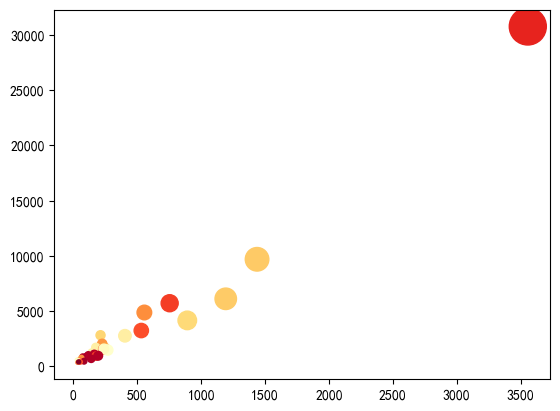

In [29]:
import pandas as pd  # 导入pandas模块
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块
import numpy as np  # 导入numpy模块

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码

# 读取Excel文件
df = pd.read_excel("../datas/JD202001.xlsx")
# x,y轴数据
x = df["成交商品件数"]
y = df["访客数"]
n = len(df)  # 计算数据行数 n=33
s = df["成交商品件数"] / 5  # 气泡大小，这里用成交商品件数除以5作为气泡的大小

# 绘制气泡图
# c参数表示颜色cmap参数表示颜色地图，YlOrRd = yellow-orange-red
plt.scatter(x, y, s, c=np.random.rand(n), cmap="YlOrRd")
plt.show()  # 显示图表

- 棉棒图

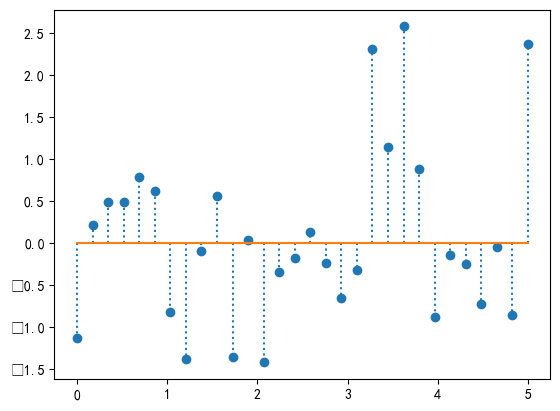

In [37]:
# 绘制棉棒图
import matplotlib.pyplot as plt  # 导入matplotlib模块
import numpy as np  # 导入numpy模块
plt.rcParams["font.sans-serif"] = ["SimHei"]

# 生成数据集
x = np.linspace(0, 5, 30)
y = np.random.randn(30)
# linefmt线条样式，markerfmt棉棒末端的样式，basefmt指定基线的样式
plt.stem(x, y, linefmt=":", markerfmt="o", basefmt="-")
plt.show()  # 显示图表

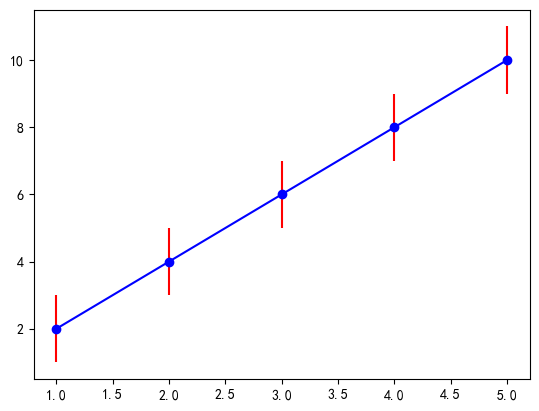

In [38]:
import matplotlib.pyplot as plt  # 导入matplotlib模块

# 绘制误差棒图，yerr为y轴水平的误差，fmt标记形状与线条样式的缩写，ecolor误差棒的颜色
plt.errorbar(x=[1, 2, 3, 4, 5], y=[2, 4, 6, 8, 10], yerr=1, fmt="bo-", ecolor="r")
plt.show()  # 显示图表